## **Q1: What is the geographic distribution, disability profile, and enrollment share of learners with diagnosed disabilities and learners with recorded manifestations, and which municipalities have the highest absolute numbers and proportions relative to total enrollment, by diagnosis and manifestation type?**

**Datasets used in this notebook**

| File | Role |
|---|---|
| `sned_database_tidy_long.parquet` (66M rows, learner-level, tidy/long format) | SNED learner counts by school, disability category, diagnosis type, grade, and sex. Queried through DuckDB throughout so the raw table is never loaded into pandas. |
| `SY 2025-2026 SCHOOL LEVEL DATA ON ENROLLMENT BY SCHOOL.xlsx` | Total enrollment per school. Needed to turn raw learner counts into enrollment-adjusted *prevalence rates*. |
| `public_school_coordinates.parquet` / `private_school_coordinates.parquet` | Supplies each school's urban/rural classification. |

### **A. Initial Checks**

In [1]:
# Assumes the repo layout implied by `_ROOT`/`DATA` below: this notebook lives one level
# below the project root, and raw + external data live in a sibling `data/` folder.
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
import geopandas as gpd
import duckdb
from scipy import stats
pd.set_option('display.max_columns', None)

# Human-readable region labels — raw psgc_region_name strings are long
# and clutter chart axes/legends
REGION_SHORT = {
    'Region I (Ilocos Region)':       'Ilocos Region',
    'Region II (Cagayan Valley)':     'Cagayan Valley',
    'Cordillera Administrative Region (CAR)': 'CAR',
    'Region III (Central Luzon)':     'Central Luzon',
    'National Capital Region (NCR)':  'NCR',
    'Region IV-A (CALABARZON)':       'CALABARZON',
    'MIMAROPA Region':                'MIMAROPA',
    'Region V (Bicol Region)':        'Bicol Region',
    'Region VI (Western Visayas)':    'Western Visayas',
    'Negros Island Region (NIR)':     'NIR',
    'Region VII (Central Visayas)':   'Central Visayas',
    'Region VIII (Eastern Visayas)':  'Eastern Visayas',
    'Region IX (Zamboanga Peninsula)':'Zamboanga Peninsula',
    'Region X (Northern Mindanao)':   'Northern Mindanao',
    'Region XI (Davao Region)':       'Davao Region',
    'Region XII (SOCCSKSARGEN)':      'SOCCSKSARGEN',
    'Region XIII (Caraga)':           'Caraga',
    'Bangsamoro Autonomous Region In Muslim Mindanao (BARMM)': 'BARMM',
}
REGION_ORDER = list(REGION_SHORT.values())

# Add near the top of your notebook (setup section), alongside REGION_SHORT —
# same idea: keep the crosswalk in one place so every chart that touches
# Category labels stays consistent, rather than re-abbreviating ad hoc per slide.
MANIFESTATION_ABBREV = {
    'Difficulty in Remembering, Concentrating, Paying Attention and Understanding': 'DRCPAU',
    'Difficulty in Applying Knowledge':                    'DAK',
    'Difficulty in Seeing':                                'DSeeing',
    'Difficulty in Communicating':                         'DComm',
    'Difficulty in Displaying Inter-Personal Behavior':    'DDIB',
    'Difficulty in Mobility (Walking, Climbing and Grasping)': 'DMobility',
    'Difficulty in Applying Adaptive Skills':              'DAAS',
    'Difficulty in Hearing':                                'DHearing',
}

DIAGNOSED_ABBREV = {
    'Autism Spectrum Disorder':                'ASD',
    'Intellectual Disability':                 'ID',
    'Learning Disability':                     'LD',
    'Speech/Language Disorder':                 'S/LD',
    'Visual Impairment':                        'VI',
    'Hearing Impairment':                       'HI',
    'Orthopedic/Physical Handicap':             'O/PH',
    'Emotional-Behavioral Disorder':            'EBD',
    'Multiple Disabilities':                    'MD',
    'Special Health Problem/Chronic Disease':   'SHP/CD',
    'Cerebral Palsy':                           'CP',
}

CATEGORY_ABBREV = {**MANIFESTATION_ABBREV, **DIAGNOSED_ABBREV}  # combined lookup for anything that mixes both types

# Optional: only keep this if you're deliberately using Inter in these charts.
from pyfonts import set_default_font, load_google_font
regular = load_google_font("Inter")
bold    = load_google_font("Inter", weight="bold")
set_default_font(regular)

_ROOT = Path.cwd().parent
DATA  = _ROOT / "data"

DIAGNOSED  = 'With Diagnosis from Licensed Medical Specialist'
MANIFEST   = 'With Manifestations'

SNED_PARQUET   = DATA / "sned_database_tidy_long.parquet"
ENROLL_XLSX    = DATA / "external" / "SY 2025-2026 SCHOOL LEVEL DATA ON ENROLLMENT BY SCHOOL.xlsx"  # adjust to your actual filename/spacing
PUBLIC_COORDS  = DATA / "external" / "public_school_coordinates.parquet"
PRIVATE_COORDS = DATA / "external" / "private_school_coordinates.parquet"

con = duckdb.connect()  # in-memory DuckDB — only used to push aggregation down to the 66M-row parquet
con.execute(f"SELECT COUNT(*) AS n_rows FROM read_parquet('{SNED_PARQUET.as_posix()}')").df()

,n_rows
0,66116694


In [2]:
# Total SNED learners nationally, public vs. private
q = f"""
SELECT
    Sector,
    SUM(Learner_Count) AS total_learners,
    SUM(CASE WHEN Diagnosis_Type = '{DIAGNOSED}' THEN Learner_Count ELSE 0 END) AS diagnosed_learners,
    SUM(CASE WHEN Diagnosis_Type = '{MANIFEST}'  THEN Learner_Count ELSE 0 END) AS manifestation_learners
FROM read_parquet('{SNED_PARQUET.as_posix()}')
GROUP BY Sector
ORDER BY total_learners DESC
"""
sned_by_sector = con.execute(q).df()
sned_by_sector['pct_of_national'] = (sned_by_sector['total_learners'] / sned_by_sector['total_learners'].sum() * 100).round(2)
sned_by_sector['diagnosed_pct'] = (sned_by_sector['diagnosed_learners'] / sned_by_sector['total_learners'] * 100).round(2)
sned_by_sector['manifestation_pct'] = (sned_by_sector['manifestation_learners'] / sned_by_sector['total_learners'] * 100).round(2)

national_total = sned_by_sector['total_learners'].sum()
print(f"National total SNED learners (sum of Learner_Count across all rows): {national_total:,.0f}")
sned_by_sector

National total SNED learners (sum of Learner_Count across all rows): 523,939


,Sector,total_learners,diagnosed_learners,manifestation_learners,pct_of_national,diagnosed_pct,manifestation_pct
0,Public,492902.0,180519.0,312383.0,94.08,36.62,63.38
1,Private,31037.0,24445.0,6592.0,5.92,78.76,21.24


In [3]:
# Provinces with highest total learners, highest diagnosed, highest manifestation
q = f"""
SELECT
    Region, Province,
    SUM(Learner_Count)                                                        AS total_learners,
    SUM(CASE WHEN Diagnosis_Type = '{DIAGNOSED}' THEN Learner_Count ELSE 0 END) AS diagnosed_learners,
    SUM(CASE WHEN Diagnosis_Type = '{MANIFEST}'  THEN Learner_Count ELSE 0 END) AS manifestation_learners
FROM read_parquet('{SNED_PARQUET.as_posix()}')
GROUP BY Region, Province
"""
province_totals = con.execute(q).df()
province_totals["ratio"] = province_totals["diagnosed_learners"] / province_totals["manifestation_learners"]
# NOTE: ratio is +inf for any province with diagnosed_learners > 0 and manifestation_learners == 0, and NaN if both are 0.

top15_total         = province_totals.sort_values('total_learners', ascending=False).head(15)
top15_diagnosed      = province_totals.sort_values('diagnosed_learners', ascending=False).head(15)
top15_manifestation  = province_totals.sort_values('manifestation_learners', ascending=False).head(15)

top15_diagnosed.sort_values('diagnosed_learners', ascending=False)

,Region,Province,total_learners,diagnosed_learners,manifestation_learners,ratio
5,NCR,NCR SECOND DISTRICT,19596.0,14264.0,5332.0,2.675169
28,NCR,NCR FOURTH DISTRICT,13173.0,9964.0,3209.0,3.105017
56,Region IV-A,CAVITE,16027.0,9715.0,6312.0,1.539132
58,Region VII,CEBU,22808.0,8652.0,14156.0,0.611190
22,Region IV-A,LAGUNA,14380.0,7746.0,6634.0,1.167621
69,Region I,PANGASINAN,24818.0,7667.0,17151.0,0.447029
41,Region XI,DAVAO DEL SUR,20019.0,7039.0,12980.0,0.542296
2,Region IV-A,BATANGAS,9246.0,6854.0,2392.0,2.865385
29,Region IV-A,RIZAL,8701.0,6733.0,1968.0,3.421240
21,Region III,BULACAN,8859.0,6537.0,2322.0,2.815245


In [4]:
top15_manifestation.sort_values('manifestation_learners', ascending=False)

,Region,Province,total_learners,diagnosed_learners,manifestation_learners,ratio
60,Region XI,DAVAO ORIENTAL,22800.0,1746.0,21054.0,0.082930
57,Region V,CAMARINES SUR,24160.0,4891.0,19269.0,0.253827
69,Region I,PANGASINAN,24818.0,7667.0,17151.0,0.447029
58,Region VII,CEBU,22808.0,8652.0,14156.0,0.611190
40,Region IX,ZAMBOANGA DEL SUR,17271.0,3251.0,14020.0,0.231883
41,Region XI,DAVAO DEL SUR,20019.0,7039.0,12980.0,0.542296
39,Region VI,ILOILO,19260.0,6477.0,12783.0,0.506689
55,Region II,ISABELA,15455.0,3296.0,12159.0,0.271075
62,NIR,NEGROS OCCIDENTAL,13007.0,5227.0,7780.0,0.671851
4,Region IX,ZAMBOANGA SIBUGAY,8391.0,1145.0,7246.0,0.158018


In [5]:
diag_keys     = set(zip(top15_diagnosed['Region'], top15_diagnosed['Province']))
manifest_keys = set(zip(top15_manifestation['Region'], top15_manifestation['Province']))
both_keys     = diag_keys & manifest_keys

print(f"Diagnosed top 15:      {len(diag_keys)} provinces")
print(f"Manifestation top 15:  {len(manifest_keys)} provinces")
print(f"Overlap (both lists):  {len(both_keys)} provinces")
print(f"Diagnosed-only:        {len(diag_keys - manifest_keys)} provinces")
print(f"Manifestation-only:    {len(manifest_keys - diag_keys)} provinces")

Diagnosed top 15:      15 provinces
Manifestation top 15:  15 provinces
Overlap (both lists):  8 provinces
Diagnosed-only:        7 provinces
Manifestation-only:    7 provinces


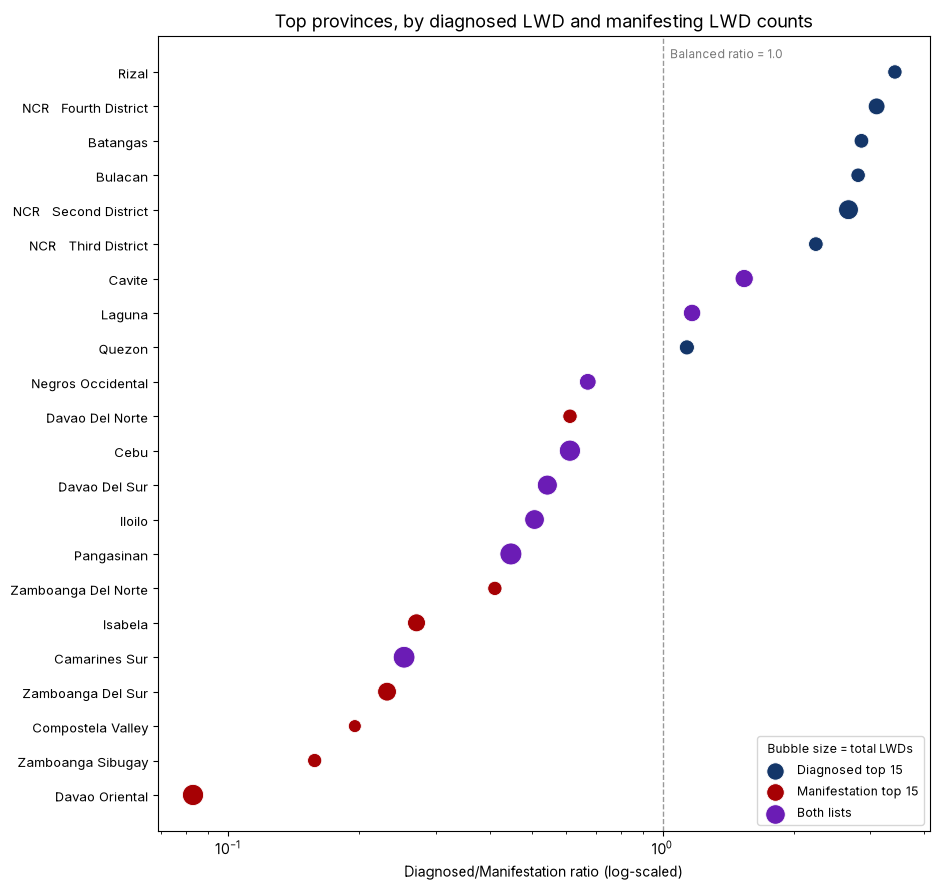

In [6]:
def clean_label(s):
    s = str(s).title()
    return s.replace('Ncr', 'NCR')

MEMBERSHIP_COLORS = {
    'Diagnosed top 15':      '#143669',  # same blue used for "diagnosed-majority" earlier in the deck
    'Manifestation top 15':  '#a60104',  # same red used for "manifestation-majority" earlier
    'Both lists':            "#6B1CB5",  # distinct third color — these are "big," not "extreme"
}

combined = pd.concat([top15_diagnosed, top15_manifestation], ignore_index=True)
combined['key'] = list(zip(combined['Region'], combined['Province']))
combined = combined.drop_duplicates(subset='key').reset_index(drop=True)
combined['membership'] = combined['key'].map(
    lambda k: 'Both lists' if k in both_keys else ('Diagnosed top 15' if k in diag_keys else 'Manifestation top 15')
)
combined = combined.sort_values('ratio', ascending=True).reset_index(drop=True)
combined['label'] = combined['Province'].apply(clean_label)

fig, ax = plt.subplots(figsize=(9.5, 9))
y_pos = np.arange(len(combined))
sizes = 30 + 220 * (combined['total_learners'] / combined['total_learners'].max())  # bubble area ∝ total learners

for membership, color in MEMBERSHIP_COLORS.items():
    mask = (combined['membership'] == membership).values
    ax.scatter(combined.loc[mask, 'ratio'], y_pos[mask], s=sizes[mask],
               color=color, label=membership, zorder=3, edgecolor='white', linewidth=0.6)

ax.set_xscale('log')
ax.axvline(1.0, color='#999999', linestyle='--', linewidth=1, zorder=1)
ax.text(1.04, len(combined) - 0.6, 'Balanced ratio = 1.0', fontsize=8.5, color='#777777', ha='left')

ax.set_yticks(y_pos)
ax.set_yticklabels(combined['label'], fontsize=9.5)
ax.set_xlabel('Diagnosed/Manifestation ratio (log-scaled)')
ax.set_title('Top provinces, by diagnosed LWD and manifesting LWD counts', fontsize=13)
ax.legend(loc='lower right', frameon=True, fontsize=9, title='Bubble size = total LWDs', title_fontsize=8.5)

plt.tight_layout()
# plt.savefig('province_diagnosed_manifestation_overlap.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

In [7]:
# Provinces where diagnosed > manifestation, tallied by region — a coarse read on where
# access to a FORMAL diagnosis (vs. a manifestation-only record) looks relatively better.
province_totals[province_totals["diagnosed_learners"] > province_totals["manifestation_learners"]]["Region"].value_counts()

Region
Region III     6
Region IV-A    5
NCR            4
Region I       2
BARMM          2
Region X       1
Region VIII    1
Region VI      1
MIMAROPA       1
NIR            1
Name: count, dtype: int64

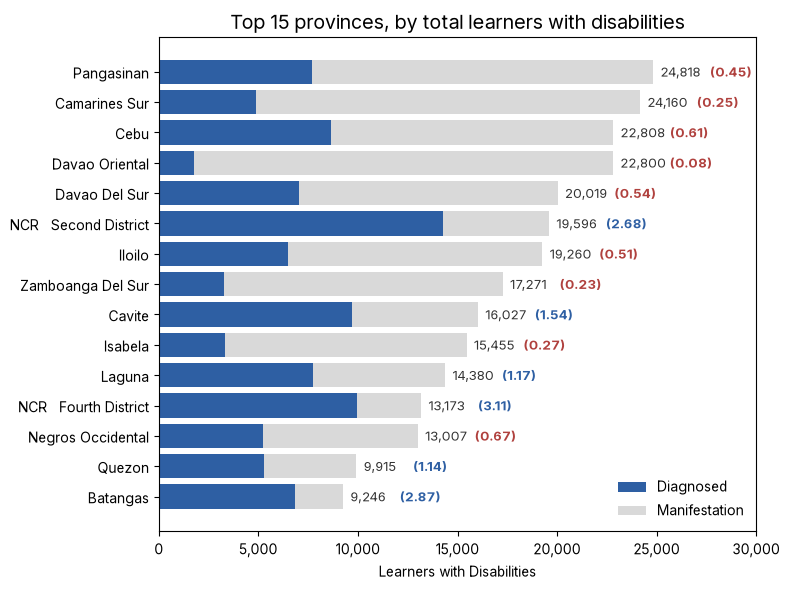

In [8]:
def clean_label(s):
    s = str(s).title()
    return s.replace('Ncr', 'NCR')

COLOR_DIAGNOSED     = '#2E5FA3'
COLOR_MANIFESTATION = '#D9D9D9'
COLOR_RATIO_HIGH     = '#2E5FA3'  # ratio >= 1: diagnosed-majority
COLOR_RATIO_LOW      = '#B0413E'  # ratio < 1: manifestation-majority
N_TOP = 15

top_provinces = top15_total.copy().iloc[::-1]  # reverse so the largest bar ends up at the TOP
top_provinces['label'] = top_provinces['Province'].apply(clean_label)

fig, ax = plt.subplots(figsize=(8, 6))
y_pos = range(len(top_provinces))

ax.barh(y_pos, top_provinces['diagnosed_learners'], color=COLOR_DIAGNOSED, label='Diagnosed')
ax.barh(y_pos, top_provinces['manifestation_learners'], left=top_provinces['diagnosed_learners'],
        color=COLOR_MANIFESTATION, label='Manifestation')

ax.set_yticks(y_pos)
ax.set_xlim(0, 30000)
ax.set_yticklabels(top_provinces['label'], fontsize=10)
ax.set_xlabel('Learners with Disabilities')
ax.set_title(f'Top {N_TOP} provinces, by total learners with disabilities', fontsize=14)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(loc='lower right', frameon=False)

x_offset = top_provinces['total_learners'].max() * 0.015
for i, (total, ratio) in enumerate(zip(top_provinces['total_learners'], top_provinces['ratio'])):
    ratio_color = COLOR_RATIO_HIGH if ratio >= 1 else COLOR_RATIO_LOW
    ax.text(total + x_offset, i, f'{int(total):,}', va='center', fontsize=9.5, color='#333333')
    ax.text(total + x_offset + top_provinces['total_learners'].max()*0.1, i, f'({ratio:.2f})',
            va='center', fontsize=9.5, fontproperties=bold, color=ratio_color)

plt.tight_layout()
# plt.savefig('top_provinces_sned.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

In [9]:
# Top disability categories — diagnosed and manifestation, counts + % shares
q = f"""
SELECT
    Diagnosis_Type, Category,
    SUM(Learner_Count) AS learner_count
FROM read_parquet('{SNED_PARQUET.as_posix()}')
GROUP BY Diagnosis_Type, Category
ORDER BY Diagnosis_Type, learner_count DESC
"""
category_totals = con.execute(q).df()

category_totals['pct_of_all_sned_learners'] = (category_totals['learner_count'] / national_total * 100).round(2)
category_totals['pct_within_own_diagnosis_type'] = (
    category_totals['learner_count'] / category_totals.groupby('Diagnosis_Type')['learner_count'].transform('sum') * 100
).round(2)

top_diagnosed_categories     = category_totals[category_totals['Diagnosis_Type'] == DIAGNOSED].sort_values('learner_count', ascending=False)
top_manifestation_categories = category_totals[category_totals['Diagnosis_Type'] == MANIFEST].sort_values('learner_count', ascending=False)

top_diagnosed_categories

,Diagnosis_Type,Category,learner_count,pct_of_all_sned_learners,pct_within_own_diagnosis_type
0,With Diagnosis from Licensed Medical Specialist,Autism Spectrum Disorder,77217.0,14.74,37.67
1,With Diagnosis from Licensed Medical Specialist,Intellectual Disability,37019.0,7.07,18.06
2,With Diagnosis from Licensed Medical Specialist,Learning Disability,22131.0,4.22,10.80
3,With Diagnosis from Licensed Medical Specialist,Speech/Language Disorder,13894.0,2.65,6.78
4,With Diagnosis from Licensed Medical Specialist,Visual Impairment,13794.0,2.63,6.73
5,With Diagnosis from Licensed Medical Specialist,Hearing Impairment,11969.0,2.28,5.84
6,With Diagnosis from Licensed Medical Specialist,Orthopedic/Physical Handicap,6952.0,1.33,3.39
7,With Diagnosis from Licensed Medical Specialist,Emotional-Behavioral Disorder,6760.0,1.29,3.30
8,With Diagnosis from Licensed Medical Specialist,Multiple Disabilities,6570.0,1.25,3.21
9,With Diagnosis from Licensed Medical Specialist,Special Health Problem/Chronic Disease,5252.0,1.00,2.56


In [10]:
# Guardrail
unmapped = set(category_totals['Category'].unique()) - set(CATEGORY_ABBREV.keys())
if unmapped:
    print("WARNING — categories with no abbreviation mapping:", unmapped)
else:
    print("OK — every Category value in category_totals is covered by CATEGORY_ABBREV.")

OK — every Category value in category_totals is covered by CATEGORY_ABBREV.


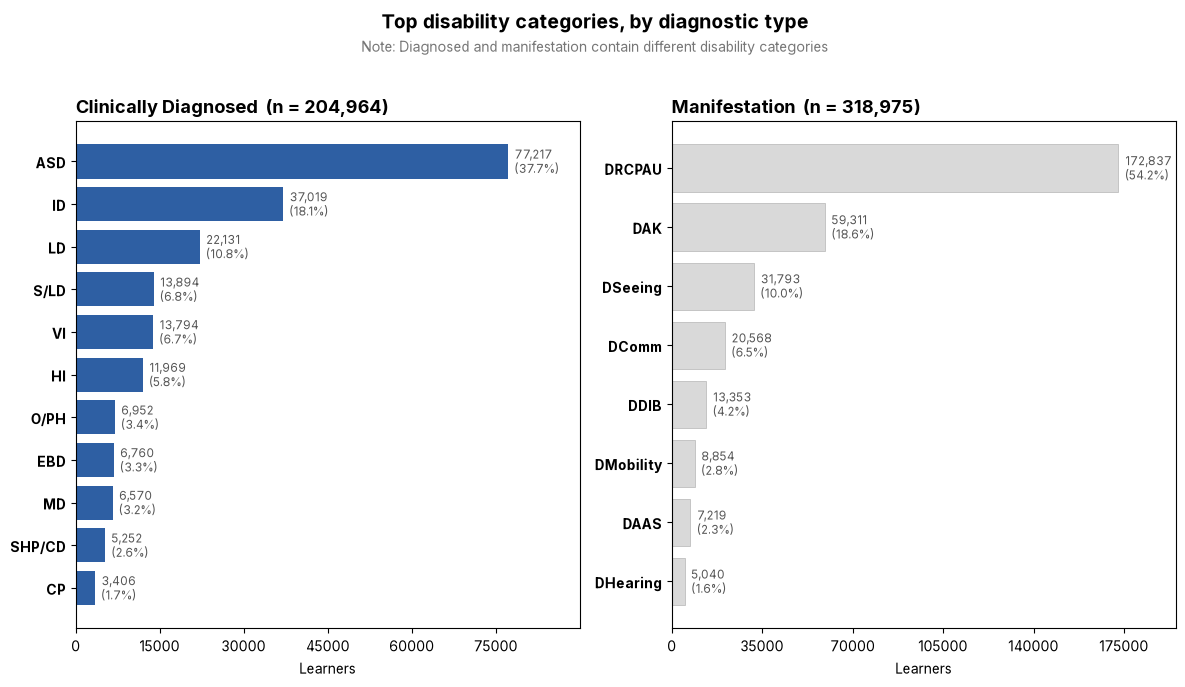

In [11]:
import matplotlib.pyplot as plt

COLOR_DIAGNOSED     = '#2E5FA3'
COLOR_MANIFESTATION = '#D9D9D9'

d = top_diagnosed_categories.sort_values('learner_count').copy()
m = top_manifestation_categories.sort_values('learner_count').copy()
d['abbrev'] = d['Category'].map(CATEGORY_ABBREV)
m['abbrev'] = m['Category'].map(CATEGORY_ABBREV)

fig, axes = plt.subplots(1, 2, figsize=(12, 6.5))

axes[0].barh(range(len(d)), d['learner_count'], color=COLOR_DIAGNOSED)
axes[0].set_yticks(range(len(d)))
axes[0].set_yticklabels(d['abbrev'], fontsize=11, fontproperties=bold)
axes[0].set_title(f'Clinically Diagnosed  (n = {int(d["learner_count"].sum()):,})', fontproperties=bold, fontsize=13, loc='left')
axes[0].set_xlabel('Learners')
axes[0].set_xlim(0,90000)
axes[0].set_xticks(np.arange(0, 90000, 15000))
for i, (val, pct) in enumerate(zip(d['learner_count'], d['pct_within_own_diagnosis_type'])):
    axes[0].text(val + d['learner_count'].max()*0.015, i, f'{int(val):,}\n({pct:.1f}%)', va='center', fontsize=8.5, color='#555555')

axes[1].barh(range(len(m)), m['learner_count'], color=COLOR_MANIFESTATION, edgecolor='#B5B5B5', linewidth=0.5)
axes[1].set_yticks(range(len(m)))
axes[1].set_yticklabels(m['abbrev'], fontsize=11, fontproperties=bold)
axes[1].set_title(f'Manifestation  (n = {int(m["learner_count"].sum()):,})', fontproperties=bold, fontsize=13, loc='left')
axes[1].set_xlabel('Learners')
axes[1].set_xlim(0,195000)
axes[1].set_xticks(np.arange(0, 195000, 35000))
for i, (val, pct) in enumerate(zip(m['learner_count'], m['pct_within_own_diagnosis_type'])):
    axes[1].text(val + m['learner_count'].max()*0.015, i, f'{int(val):,}\n({pct:.1f}%)', va='center', fontsize=8.5, color='#555555')

fig.suptitle('Top disability categories, by diagnostic type', fontproperties=bold, fontsize=14, y=1.05)
fig.text(0.5, 0.985, 'Note: Diagnosed and manifestation contain different disability categories',
          fontsize=10, ha='center', color='#777777')

plt.tight_layout()
# plt.savefig('top_categories_sned_abbrev.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

In [12]:
# Municipalities with highest learner counts, and % diagnosed / % manifestation within each
q = f"""
SELECT
    Region, Province, Municipality,
    SUM(Learner_Count)                                                        AS total_learners,
    SUM(CASE WHEN Diagnosis_Type = '{DIAGNOSED}' THEN Learner_Count ELSE 0 END) AS diagnosed_learners,
    SUM(CASE WHEN Diagnosis_Type = '{MANIFEST}'  THEN Learner_Count ELSE 0 END) AS manifestation_learners
FROM read_parquet('{SNED_PARQUET.as_posix()}')
GROUP BY Region, Province, Municipality
"""
municipality_totals = con.execute(q).df()
municipality_totals['pct_diagnosed']     = (municipality_totals['diagnosed_learners']    / municipality_totals['total_learners'] * 100).round(2)
municipality_totals['pct_manifestation'] = (municipality_totals['manifestation_learners'] / municipality_totals['total_learners'] * 100).round(2)

# NOTE: these are RAW learner counts, not enrollment-adjusted. A municipality can rank
# highest here simply because it has a lot of schools/pupils overall — see Section B for
# prevalence rates (learners ÷ total enrollment), which control for that.
top20_municipalities_by_total = municipality_totals.sort_values('total_learners', ascending=False).head(20)
top20_municipalities_by_total

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,Region,Province,Municipality,total_learners,diagnosed_learners,manifestation_learners,pct_diagnosed,pct_manifestation
846,Region XI,DAVAO DEL SUR,DAVAO CITY,17218.0,6137.0,11081.0,35.64,64.36
31,NCR,NCR SECOND DISTRICT,QUEZON CITY,9397.0,7841.0,1556.0,83.44,16.56
936,Region IV-A,CAVITE,CITY OF GENERAL TRIAS,4849.0,1893.0,2956.0,39.04,60.96
617,Region XII,SOUTH COTABATO,GENERAL SANTOS CITY (DADIANGAS),4383.0,1714.0,2669.0,39.11,60.89
832,Region VII,CEBU,CEBU CITY (Capital),4275.0,2238.0,2037.0,52.35,47.65
1515,Region XI,DAVAO ORIENTAL,LUPON,3967.0,139.0,3828.0,3.50,96.50
656,NCR,NCR SECOND DISTRICT,CITY OF PASIG,3565.0,2624.0,941.0,73.60,26.40
765,NCR,NCR SECOND DISTRICT,CITY OF MANDALUYONG,3549.0,1983.0,1566.0,55.87,44.13
681,Region XI,DAVAO ORIENTAL,CITY OF MATI (Capital),3435.0,359.0,3076.0,10.45,89.55
428,NIR,NEGROS OCCIDENTAL,SAGAY CITY,3334.0,426.0,2908.0,12.78,87.22


In [13]:
municipality_totals

,Region,Province,Municipality,total_learners,diagnosed_learners,manifestation_learners,pct_diagnosed,pct_manifestation
0,Region I,LA UNION,LUNA,61.0,15.0,46.0,24.59,75.41
1,Region I,PANGASINAN,UMINGAN,908.0,212.0,696.0,23.35,76.65
2,Region II,ISABELA,TUMAUINI,608.0,121.0,487.0,19.90,80.10
3,Region IV-A,RIZAL,TAYTAY,879.0,715.0,164.0,81.34,18.66
4,MIMAROPA,ROMBLON,CORCUERA,19.0,8.0,11.0,42.11,57.89
...,...,...,...,...,...,...,...,...
1651,CARAGA,DINAGAT ISLANDS,SAN JOSE (Capital),252.0,71.0,181.0,28.17,71.83
1652,NIR,NEGROS OCCIDENTAL,CITY OF ESCALANTE,624.0,144.0,480.0,23.08,76.92
1653,Region V,CAMARINES SUR,NAGA CITY,1365.0,877.0,488.0,64.25,35.75
1654,Region VII,BOHOL,SAGBAYAN (BORJA),368.0,90.0,278.0,24.46,75.54


In [14]:
top_muni_per_province = (
    municipality_totals.sort_values('total_learners', ascending=False)
    .groupby(['Region', 'Province'], as_index=False).first()
    .rename(columns={'Municipality': 'top_municipality', 'total_learners': 'top_muni_learners'})
)

province_concentration = top15_total.merge(
    top_muni_per_province[['Region', 'Province', 'top_municipality', 'top_muni_learners']],
    on=['Region', 'Province'], how='left'
)
province_concentration['top_muni_share_pct'] = (
    province_concentration['top_muni_learners'] / province_concentration['total_learners'] * 100
).round(1)

province_concentration[['Province', 'total_learners', 'top_municipality', 'top_muni_learners', 'top_muni_share_pct']].sort_values('top_muni_share_pct', ascending=False)

,Province,total_learners,top_municipality,top_muni_learners,top_muni_share_pct
4,DAVAO DEL SUR,20019.0,DAVAO CITY,17218.0,86.0
5,NCR SECOND DISTRICT,19596.0,QUEZON CITY,9397.0,48.0
13,QUEZON,9915.0,LUCENA CITY (Capital),3027.0,30.5
8,CAVITE,16027.0,CITY OF GENERAL TRIAS,4849.0,30.3
12,NEGROS OCCIDENTAL,13007.0,SAGAY CITY,3334.0,25.6
11,NCR FOURTH DISTRICT,13173.0,TAGUIG CITY,2817.0,21.4
10,LAGUNA,14380.0,CITY OF BIÑAN,2794.0,19.4
2,CEBU,22808.0,CEBU CITY (Capital),4275.0,18.7
3,DAVAO ORIENTAL,22800.0,LUPON,3967.0,17.4
6,ILOILO,19260.0,ILOILO CITY (Capital),3022.0,15.7


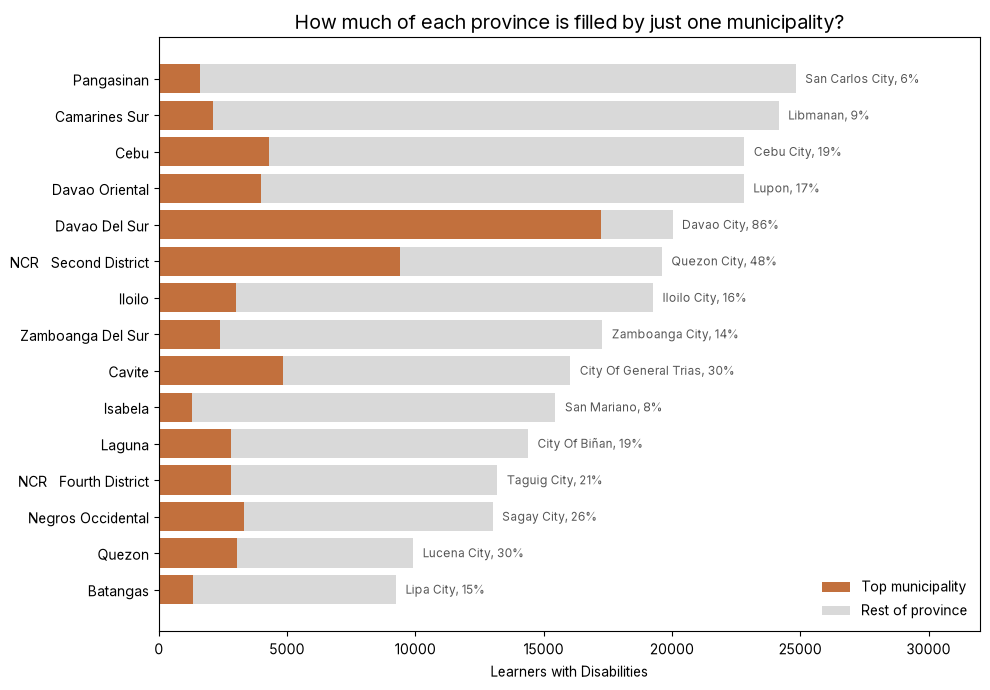

In [15]:
COLOR_TOP_MUNI      = '#C2703D'   # distinct from the diagnosed/manifestation blue-gray pair used earlier
COLOR_REST_PROVINCE = '#D9D9D9'

def clean_label(s):
    s = str(s).title()
    return s.replace('Ncr', 'NCR')

pc = province_concentration.sort_values('total_learners', ascending=True).copy()  # ascending -> highest concentration at top of chart
pc["Province"] = pc['Province'].apply(clean_label)
pc['rest_of_province'] = pc['total_learners'] - pc['top_muni_learners']
pc['muni_label'] = pc['top_municipality'].str.replace(r'\s*\(Capital\)', '', regex=True).str.title()

fig, ax = plt.subplots(figsize=(10, 7))
y_pos = range(len(pc))

ax.barh(y_pos, pc['top_muni_learners'], color=COLOR_TOP_MUNI, label='Top municipality')
ax.barh(y_pos, pc['rest_of_province'], left=pc['top_muni_learners'], color=COLOR_REST_PROVINCE, label='Rest of province')

ax.set_yticks(y_pos)
ax.set_yticklabels(pc['Province'].str.title().apply(clean_label), fontsize=10)
ax.set_xlabel('Learners with Disabilities')
ax.set_xlim(0, 32000)
ax.set_title('How much of each province is filled by just one municipality?', fontsize=14)
ax.legend(loc='lower right', frameon=False)

for i, (total, muni, pct) in enumerate(zip(pc['total_learners'], pc['muni_label'], pc['top_muni_share_pct'])):
    ax.text(total + pc['total_learners'].max()*0.015, i, f'{muni}, {pct:.0f}%',
            va='center', fontsize=8.5, color='#555555')

plt.tight_layout()
# plt.savefig('province_municipality_concentration.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

### **B. School-level Denominators, Prevalence Rates**

In [16]:
# School-level enrollment
enroll_raw = pd.read_excel(ENROLL_XLSX, sheet_name="DATABASE", header=5)

enroll_count_cols = [c for c in enroll_raw.columns if isinstance(c, str) and
                      (c.startswith('k') or c.startswith('g') or c.startswith('ng'))]
enroll_raw[enroll_count_cols] = enroll_raw[enroll_count_cols].apply(pd.to_numeric, errors='coerce')
enroll_raw['total_enrollment'] = enroll_raw[enroll_count_cols].sum(axis=1, skipna=True)

school_master = enroll_raw[[
    'beis_school_id', 'Region', 'Division', 'Province', 'Municipality',
    'Leg_district', 'Barangay', 'Sector', 'total_enrollment'
]].copy()

print(f"Schools in enrollment master: {len(school_master):,}")
print(school_master['Sector'].value_counts(dropna=False))

# SNED totals per school, from the big parquet
q = f"""
SELECT
    beis_school_id,
    SUM(Learner_Count)                                                        AS total_learners,
    SUM(CASE WHEN Diagnosis_Type = '{DIAGNOSED}' THEN Learner_Count ELSE 0 END) AS diagnosed_learners,
    SUM(CASE WHEN Diagnosis_Type = '{MANIFEST}'  THEN Learner_Count ELSE 0 END) AS manifestation_learners
FROM read_parquet('{SNED_PARQUET.as_posix()}')
GROUP BY beis_school_id
"""
sned_by_school = con.execute(q).df()

# Category x Diagnosis_Type x Sex per school
q = f"""
SELECT
    beis_school_id, Diagnosis_Type, Category, Sex,
    SUM(Learner_Count) AS learner_count
FROM read_parquet('{SNED_PARQUET.as_posix()}')
GROUP BY beis_school_id, Diagnosis_Type, Category, Sex
"""
sned_by_school_category = con.execute(q).df()

# Master joins: school_master is the LEFT side (full universe of schools), so absent-from-SNED schools correctly show up as 0
school_level = school_master.merge(sned_by_school, on='beis_school_id', how='left')
school_level[['total_learners','diagnosed_learners','manifestation_learners']] = \
    school_level[['total_learners','diagnosed_learners','manifestation_learners']].fillna(0)

category_level = sned_by_school_category.merge(
    school_master.drop(columns='total_enrollment'), on='beis_school_id', how='left'
)

print(f"school_level shape: {school_level.shape}")
print(f"category_level shape: {category_level.shape}")
print(f"Unmatched beis_school_id (in SNED parquet but not in enrollment master): "
      f"{sned_by_school['beis_school_id'].nunique() - school_level.loc[school_level['total_learners']>0,'beis_school_id'].nunique()}")

Schools in enrollment master: 60,204
Sector
Public      48129
Private     11868
SUCsLUCs      171
PSO            36
Name: count, dtype: int64


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

school_level shape: (60204, 12)
category_level shape: (2279886, 12)
Unmatched beis_school_id (in SNED parquet but not in enrollment master): 21649


In [17]:
def add_quantile_band(df, value_col, low_q=0.25, high_q=0.75, band_col='band'):
    """Tags rows into Low / Medium / High using the value column's own 25th/75th percentile."""
    q_low, q_high = df[value_col].quantile([low_q, high_q])
    conditions = [df[value_col] <= q_low, df[value_col] >= q_high]
    choices = [f'Low (0–{int(low_q*100)}th pctile)', f'High ({int(high_q*100)}th–100th pctile)']
    df = df.copy()
    df[band_col] = np.select(conditions, choices, default=f'Medium ({int(low_q*100)}th–{int(high_q*100)}th pctile)')
    return df, (q_low, q_high)

def concentration_ratio(df, count_col, top_n=5):
    """CR-k: share of the total held by the top-k groups. Standard industrial-concentration metric,
    used here as a compact number to say 'how geographically concentrated is this?' """
    total = df[count_col].sum()
    if total == 0:
        return np.nan
    top_sum = df.sort_values(count_col, ascending=False).head(top_n)[count_col].sum()
    return round(top_sum / total * 100, 2)

def gini_coefficient(values):
    """0 = perfectly even spread across geographies, 1 = maximally concentrated in one place."""
    x = np.sort(np.asarray(values, dtype=float))
    x = x[x >= 0]
    n = len(x)
    if n == 0 or x.sum() == 0:
        return np.nan
    cum_x = np.cumsum(x)
    return round((n + 1 - 2 * np.sum(cum_x) / cum_x[-1]) / n, 4)

def location_quotient(df, group_col, category_col, count_col):
    """LQ = (category's share of this group) / (category's share nationally).
    LQ > 1 -> that category is over-represented in this group relative to the national mix
    (a geographic 'hotspot' for that specific disability type, not just high volume overall)."""
    grp_totals   = df.groupby(group_col)[count_col].transform('sum')
    cat_totals   = df.groupby(category_col)[count_col].transform('sum')
    grand_total  = df[count_col].sum()
    return (df[count_col] / grp_totals) / (cat_totals / grand_total)

In [18]:
# Public vs private: diagnosed/manifestation ratio and prevalence
sector_summary = school_level.groupby('Sector', as_index=False).agg(
    total_enrollment       = ('total_enrollment', 'sum'),
    total_learners         = ('total_learners', 'sum'),
    diagnosed_learners     = ('diagnosed_learners', 'sum'),
    manifestation_learners = ('manifestation_learners', 'sum'),
)
sector_summary = sector_summary[sector_summary['Sector'].isin(['Public','Private'])].copy()

sector_summary['diagnosed_to_manifestation_ratio'] = (
    sector_summary['diagnosed_learners'] / sector_summary['manifestation_learners']
).round(3)
sector_summary['sned_prevalence_pct']          = (sector_summary['total_learners']         / sector_summary['total_enrollment'] * 100).round(3)
sector_summary['diagnosed_prevalence_pct']     = (sector_summary['diagnosed_learners']     / sector_summary['total_enrollment'] * 100).round(3)
sector_summary['manifestation_prevalence_pct'] = (sector_summary['manifestation_learners'] / sector_summary['total_enrollment'] * 100).round(3)

# Formal test of whether Sector and Diagnosis_Type are independent 
contingency = sector_summary.set_index('Sector')[['diagnosed_learners','manifestation_learners']]
chi2, p, dof, expected = stats.chi2_contingency(contingency)
print(f"Chi-square (Sector x Diagnosis Type): chi2={chi2:.2f}, dof={dof}, p={p:.4g}")

sector_summary

Chi-square (Sector x Diagnosis Type): chi2=21766.13, dof=1, p=0


,Sector,total_enrollment,total_learners,diagnosed_learners,manifestation_learners,diagnosed_to_manifestation_ratio,sned_prevalence_pct,diagnosed_prevalence_pct,manifestation_prevalence_pct
1,Private,3758971.0,31037.0,24445.0,6592.0,3.708,0.826,0.650,0.175
2,Public,22078460.0,492902.0,180519.0,312383.0,0.578,2.233,0.818,1.415


In [19]:
# Checking for outliers
# Municipality-level prevalence outliers (IQR method, with a reliability floor so a 40-pupil municipality doesn't get flagged just from small-N noise) ---
muni_level = school_level.groupby(['Region','Province','Municipality'], as_index=False).agg(
    total_enrollment       = ('total_enrollment', 'sum'),
    total_learners         = ('total_learners', 'sum'),
    diagnosed_learners     = ('diagnosed_learners', 'sum'),
    manifestation_learners = ('manifestation_learners', 'sum'),
)
muni_level['sned_prevalence_pct'] = muni_level['total_learners'] / muni_level['total_enrollment'] * 100

MIN_ENROLLMENT = 500  # arbitrary reliability floor — raise/lower and see how sensitive the list is
reliable = muni_level[muni_level['total_enrollment'] >= MIN_ENROLLMENT].copy()

q1, q3 = reliable['sned_prevalence_pct'].quantile([0.25, 0.75])
iqr = q3 - q1
upper_fence, lower_fence = q3 + 1.5*iqr, max(q1 - 1.5*iqr, 0)

reliable['outlier_flag'] = np.select(
    [reliable['sned_prevalence_pct'] > upper_fence, reliable['sned_prevalence_pct'] < lower_fence],
    ['high_outlier', 'low_outlier'], default='typical'
)

high_prevalence_outliers = reliable[reliable['outlier_flag']=='high_outlier'].sort_values('sned_prevalence_pct', ascending=False)
low_prevalence_outliers  = reliable[reliable['outlier_flag']=='low_outlier'].sort_values('sned_prevalence_pct')

# 2b. True zeros / near-zeros, INCLUDING municipalities absent from the SNED data entirely
zero_sned_munis = muni_level[muni_level['total_learners'] == 0].sort_values('total_enrollment', ascending=False)

# 2c. Category-level hotspots via Location Quotient
muni_cat = category_level.groupby(['Region','Province','Municipality','Category'], as_index=False)['learner_count'].sum()
muni_cat['LQ'] = location_quotient(muni_cat, group_col='Municipality', category_col='Category', count_col='learner_count')

MIN_CAT_COUNT = 20  # ignore LQ spikes built on a handful of learners
lq_hotspots = muni_cat[muni_cat['learner_count'] >= MIN_CAT_COUNT].sort_values('LQ', ascending=False).head(30)

print(f"High-prevalence outlier municipalities: {len(high_prevalence_outliers)}")
print(f"Zero-SNED municipalities (with enrollment >0): {len(zero_sned_munis)}")
lq_hotspots.head(10)

High-prevalence outlier municipalities: 129
Zero-SNED municipalities (with enrollment >0): 9


,Region,Province,Municipality,Category,learner_count,LQ
6338,NCR,"MANILA, NCR, FIRST DISTRICT",INTRAMUROS,Hearing Impairment,51.0,39.866215
1937,BARMM,TAWI-TAWI,SAPA-SAPA,Visual Impairment,67.0,23.563595
10077,Region I,PANGASINAN,MAPANDAN,"Difficulty in Mobility (Walking, Climbing and ...",92.0,20.238427
6395,NCR,"MANILA, NCR, FIRST DISTRICT",PANDACAN,Hearing Impairment,33.0,19.260854
10400,Region I,PANGASINAN,URBIZTONDO,"Difficulty in Mobility (Walking, Climbing and ...",38.0,19.056485
9811,Region I,PANGASINAN,CALASIAO,"Difficulty in Mobility (Walking, Climbing and ...",173.0,18.087181
11373,Region II,ISABELA,GAMU,Hearing Impairment,71.0,17.659099
9754,Region I,PANGASINAN,BOLINAO,"Difficulty in Mobility (Walking, Climbing and ...",224.0,17.349856
9545,Region I,PANGASINAN,AGUILAR,"Difficulty in Mobility (Walking, Climbing and ...",45.0,13.797373
13511,Region III,NUEVA ECIJA,SAN LEONARDO,Difficulty in Applying Adaptive Skills,20.0,13.440330


In [20]:
# Geographic concentration
def concentration_table(df, group_col, count_col='learner_count', top_n=5):
    g = df.groupby(group_col, as_index=False)[count_col].sum()
    return pd.Series({
        f'n_{group_col.lower()}s_with_any_learners': (g[count_col] > 0).sum(),
        f'CR{top_n}_pct': concentration_ratio(g, count_col, top_n=top_n),
        'gini': gini_coefficient(g[count_col]),
    })

rows = []
for diag_type, label in [(DIAGNOSED, 'Diagnosed'), (MANIFEST, 'Manifestation')]:
    subset = category_level[category_level['Diagnosis_Type'] == diag_type]
    for geo_col in ['Province', 'Region']:
        stat = concentration_table(subset, geo_col)
        stat['diagnosis_type'] = label
        stat['geography'] = geo_col
        rows.append(stat)

concentration_summary = pd.DataFrame(rows)
concentration_summary

,n_provinces_with_any_learners,CR5_pct,gini,diagnosis_type,geography,n_regions_with_any_learners
0,88.0,24.56,0.5621,Diagnosed,Province,NaN
1,NaN,56.98,0.3964,Diagnosed,Region,18.0
2,88.0,26.85,0.5471,Manifestation,Province,NaN
3,NaN,46.33,0.2853,Manifestation,Region,18.0


In [21]:
# Same idea, but broken out per disability category (which categories are the MOST
# geographically concentrated, i.e. clustered in a handful of provinces rather than spread
# out — these are the ones where a few well-placed specialist facilities would go furthest)
province_by_category = category_level.groupby(['Province','Category'], as_index=False)['learner_count'].sum()

category_concentration = (
    province_by_category
    .groupby('Category')
    .apply(lambda g: pd.Series({
        'CR5_pct': concentration_ratio(g, 'learner_count', top_n=5),
        'gini': gini_coefficient(g['learner_count']),
        'total_learners': g['learner_count'].sum(),
    }))
    .reset_index()
    .sort_values('gini', ascending=False)
)
category_concentration

,Category,CR5_pct,gini,total_learners
0,Autism Spectrum Disorder,33.52,0.6700,77217.0
3,Difficulty in Applying Knowledge,38.50,0.6455,59311.0
9,Difficulty in Seeing,34.79,0.6232,31793.0
12,Intellectual Disability,24.66,0.5967,37019.0
10,Emotional-Behavioral Disorder,25.40,0.5754,6760.0
8,"Difficulty in Remembering, Concentrating, Payi...",27.25,0.5624,172837.0
11,Hearing Impairment,25.11,0.5618,11969.0
16,Special Health Problem/Chronic Disease,24.89,0.5467,5252.0
7,"Difficulty in Mobility (Walking, Climbing and ...",31.23,0.5374,8854.0
5,Difficulty in Displaying Inter-Personal Behavior,24.69,0.5365,13353.0


In [22]:
# Municipalities where private school SNED enrollment is notable
muni_sector = (
    school_level.groupby(['Region','Province','Municipality','Sector'], as_index=False)['total_learners'].sum()
    .pivot_table(index=['Region','Province','Municipality'], columns='Sector', values='total_learners', fill_value=0)
    .reset_index()
)
sector_cols = [c for c in muni_sector.columns if c in ('Public','Private','SUCsLUCs','PSO')]
muni_sector['grand_total'] = muni_sector[sector_cols].sum(axis=1)
muni_sector['private_share_pct'] = (muni_sector.get('Private', 0) / muni_sector['grand_total'].replace(0, np.nan) * 100).round(2)

national_private_share = muni_sector['Private'].sum() / muni_sector['grand_total'].sum() * 100
print(f"National private share of SNED enrollment: {national_private_share:.2f}%")

MIN_TOTAL = 20  # reliability floor, same logic as item 2
private_prominent_munis = (
    muni_sector[muni_sector['grand_total'] >= MIN_TOTAL]
    .sort_values('private_share_pct', ascending=False)
)
private_prominent_munis.head(10)

National private share of SNED enrollment: 5.92%


Sector,Region,Province,Municipality,PSO,Private,Public,SUCsLUCs,grand_total,private_share_pct
336,NCR,"MANILA, NCR, FIRST DISTRICT",PANDACAN,0.0,56.0,19.0,0.0,75.0,74.67
338,NCR,"MANILA, NCR, FIRST DISTRICT",QUIAPO,0.0,14.0,6.0,0.0,20.0,70.00
799,Region IV-A,BATANGAS,SAN PASCUAL,0.0,132.0,74.0,0.0,206.0,64.08
908,Region IV-A,RIZAL,MORONG,0.0,129.0,134.0,0.0,263.0,49.05
686,Region III,BULACAN,SANTA MARIA,0.0,378.0,489.0,0.0,867.0,43.60
795,Region IV-A,BATANGAS,SAN JOSE,0.0,68.0,135.0,0.0,203.0,33.50
668,Region III,BULACAN,BUSTOS,0.0,43.0,87.0,0.0,130.0,33.08
72,BARMM,MAGUINDANAO,MAMASAPANO,0.0,74.0,154.0,0.0,228.0,32.46
726,Region III,PAMPANGA,GUAGUA,0.0,48.0,103.0,0.0,151.0,31.79
904,Region IV-A,RIZAL,CAINTA,0.0,240.0,527.0,0.0,767.0,31.29


In [23]:
# Legislative-distict aggregation in terms of total SNED learners
legdist_level = school_level.groupby(['Region','Province','Leg_district'], as_index=False).agg(
    total_enrollment       = ('total_enrollment', 'sum'),
    total_learners         = ('total_learners', 'sum'),
    diagnosed_learners     = ('diagnosed_learners', 'sum'),
    manifestation_learners = ('manifestation_learners', 'sum'),
)
legdist_level['sned_prevalence_pct'] = legdist_level['total_learners'] / legdist_level['total_enrollment'] * 100

top20_legdist_by_total      = legdist_level.sort_values('total_learners', ascending=False).head(20)
# Arbitrary filter of 500 total students
top20_legdist_by_prevalence = legdist_level[legdist_level['total_enrollment'] >= 500].sort_values('sned_prevalence_pct', ascending=False).head(20)

top20_legdist_by_total.head(10)

,Region,Province,Leg_district,total_enrollment,total_learners,diagnosed_learners,manifestation_learners,sned_prevalence_pct
142,Region IX,ZAMBOANGA DEL SUR,1st District,289297.0,12633.0,2069.0,10564.0,4.366793
218,Region XI,DAVAO ORIENTAL,2nd District,94460.0,12323.0,832.0,11491.0,13.045734
217,Region XI,DAVAO ORIENTAL,1st District,60700.0,10477.0,914.0,9563.0,17.260297
211,Region XI,DAVAO DEL SUR,1st District,314995.0,9779.0,3925.0,5854.0,3.104494
55,NCR,NCR SECOND DISTRICT,Lone District,284344.0,8384.0,5148.0,3236.0,2.948541
177,Region VII,CEBU,1st District,334168.0,7668.0,2804.0,4864.0,2.294654
19,CAR,BENGUET,Lone District,177569.0,6591.0,3192.0,3399.0,3.711797
48,NCR,NCR FOURTH DISTRICT,Lone District,313358.0,6536.0,4509.0,2027.0,2.085793
153,Region V,CAMARINES SUR,2nd District,93427.0,6189.0,903.0,5286.0,6.624423
92,Region II,QUIRINO,Lone District,47845.0,6071.0,865.0,5206.0,12.688891


In [24]:
# Sex ratio, per disability category
sex_by_category = category_level.groupby(['Diagnosis_Type','Category','Sex'], as_index=False)['learner_count'].sum()

sex_pivot = sex_by_category.pivot_table(index=['Diagnosis_Type','Category'], columns='Sex', values='learner_count', fill_value=0)
sex_pivot['male_to_female_ratio'] = (sex_pivot.get('Male', 0) / sex_pivot.get('Female', 0).replace(0, np.nan)).round(2)
sex_pivot['pct_male'] = (sex_pivot.get('Male', 0) / (sex_pivot.get('Male', 0) + sex_pivot.get('Female', 0)) * 100).round(1)

sex_pivot.sort_values('pct_male', ascending=False)

Sex                                                                                                  Female  \
Diagnosis_Type                                  Category                                                      
With Diagnosis from Licensed Medical Specialist Autism Spectrum Disorder                            15968.0   
                                                Emotional-Behavioral Disorder                        1488.0   
With Manifestations                             Difficulty in Displaying Inter-Personal Behavior     2956.0   
                                                Difficulty in Applying Adaptive Skills               1972.0   
                                                Difficulty in Remembering, Concentrating, Payin...  52040.0   
With Diagnosis from Licensed Medical Specialist Learning Disability                                  7009.0   
With Manifestations                             Difficulty in Communicating                          6690.0   
With Diagnosis from Licensed Medical Specialist Speech/Language Disorder                             4736.0   
With Manifestations                             Difficulty in Applying Knowledge                    20865.0   
With Diagnosis from Licensed Medical Specialist Multiple Disabilities                                2375.0   
                                                Intellectual Disability                             14759.0   
                                                Orthopedic/Physical Handicap                         2829.0   
With Manifestations                             Difficulty in Mobility (Walking, Climbing and G...   3694.0   
With Diagnosis from Licensed Medical Specialist Cerebral Palsy                                       1455.0   
With Manifestations                             Difficulty in Hearing                                2193.0   
With Diagnosis from Licensed Medical Specialist Hearing Impairment                                   5651.0   
                                                Special Health Problem/Chronic Disease               2489.0   
                                                Visual Impairment                                    6715.0   
With Manifestations                             Difficulty in Seeing                                16867.0   

Sex                                                                                                     Male  \
Diagnosis_Type                                  Category                                                       
With Diagnosis from Licensed Medical Specialist Autism Spectrum Disorder                             61249.0   
                                                Emotional-Behavioral Disorder                         5272.0   
With Manifestations                             Difficulty in Displaying Inter-Personal Behavior     10397.0   
                                                Difficulty in Applying Adaptive Skills                5247.0   
                                                Difficulty in Remembering, Concentrating, Payin...  120797.0   
With Diagnosis from Licensed Medical Specialist Learning Disability                                  15122.0   
With Manifestations                             Difficulty in Communicating                          13878.0   
With Diagnosis from Licensed Medical Specialist Speech/Language Disorder                              9158.0   
With Manifestations                             Difficulty in Applying Knowledge                     38446.0   
With Diagnosis from Licensed Medical Specialist Multiple Disabilities                                 4195.0   
                                                Intellectual Disability                              22260.0   
                                                Orthopedic/Physical Handicap                          4123.0   
With Manifestations                             Difficulty in Mobility (Walking, Climbing and G...  

### **C. Municipal Rankings**

In [25]:
# Rebuild muni-level enrollment table
muni_level = school_level.groupby(['Region','Province','Municipality'], as_index=False).agg(
    total_enrollment       = ('total_enrollment', 'sum'),
    total_learners         = ('total_learners', 'sum'),
    diagnosed_learners     = ('diagnosed_learners', 'sum'),
    manifestation_learners = ('manifestation_learners', 'sum'),
)

muni_level['sned_prevalence_pct']          = (muni_level['total_learners']         / muni_level['total_enrollment'] * 100)
muni_level['diagnosed_prevalence_pct']     = (muni_level['diagnosed_learners']     / muni_level['total_enrollment'] * 100)
muni_level['manifestation_prevalence_pct'] = (muni_level['manifestation_learners'] / muni_level['total_enrollment'] * 100)

print(f"Municipalities in table: {len(muni_level):,}")
muni_level[['Region','Province','Municipality','total_enrollment','diagnosed_prevalence_pct','manifestation_prevalence_pct']].head()

Municipalities in table: 1,657


,Region,Province,Municipality,total_enrollment,diagnosed_prevalence_pct,manifestation_prevalence_pct
0,BARMM,(SGA - North Cotabato),(SGA - North Cotabato),1332.0,0.075075,0.225225
1,BARMM,BASILAN,AKBAR,1919.0,0.000000,0.000000
2,BARMM,BASILAN,AL-BARKA,2254.0,0.000000,0.044366
3,BARMM,BASILAN,CITY OF LAMITAN,27967.0,0.353989,0.371867
4,BARMM,BASILAN,HADJI MOHAMMAD AJUL,3492.0,0.000000,0.000000


In [26]:
# Drop municipalities that has a total enrollment below the 10th percentile
ENROLLMENT_P10 = muni_level['total_enrollment'].quantile(0.10)
print(f"Excluding municipalities below the 10th percentile of total enrollment ({ENROLLMENT_P10:,.0f} enrolled learners)")

reliable_munis = muni_level[muni_level['total_enrollment'] >= ENROLLMENT_P10].copy()
print(f"Municipalities remaining after filter: {len(reliable_munis):,} of {len(muni_level):,}")

TOP_N = 10
top_diagnosed_share_munis     = reliable_munis.sort_values('diagnosed_prevalence_pct', ascending=False).head(TOP_N).copy()
top_manifestation_share_munis = reliable_munis.sort_values('manifestation_prevalence_pct', ascending=False).head(TOP_N).copy()


Excluding municipalities below the 10th percentile of total enrollment (2,836 enrolled learners)
Municipalities remaining after filter: 1,491 of 1,657


In [27]:
# Top disability category per municipality, per diagnostic type
def top_category_per_municipality(category_level, diagnosis_type, geo_cols=('Region','Province','Municipality')):
    geo_cols = list(geo_cols)
    subset = category_level[category_level['Diagnosis_Type'] == diagnosis_type]
    cat_totals = subset.groupby(geo_cols + ['Category'], as_index=False)['learner_count'].sum()

    # rank='first' breaks exact ties deterministically rather than duplicating rows
    cat_totals['rank'] = cat_totals.groupby(geo_cols)['learner_count'].rank(ascending=False, method='first')
    top1 = (
        cat_totals[cat_totals['rank'] == 1]
        .drop(columns='rank')
        .rename(columns={'Category': 'top_category', 'learner_count': 'top_category_count'})
    )
    return top1

top_diagnosed_category_by_muni     = top_category_per_municipality(category_level, DIAGNOSED)
top_manifestation_category_by_muni = top_category_per_municipality(category_level, MANIFEST)

top_diagnosed_share_summary = top_diagnosed_share_munis.merge(
    top_diagnosed_category_by_muni, on=['Region','Province','Municipality'], how='left'
)[['Region','Province','Municipality','total_enrollment','diagnosed_learners',
   'diagnosed_prevalence_pct','top_category','top_category_count']]

top_manifestation_share_summary = top_manifestation_share_munis.merge(
    top_manifestation_category_by_muni, on=['Region','Province','Municipality'], how='left'
)[['Region','Province','Municipality','total_enrollment','manifestation_learners',
   'manifestation_prevalence_pct','top_category','top_category_count']]

print("--- Top municipalities by DIAGNOSED prevalence ---")
display(top_diagnosed_share_summary)

print("\n--- Top municipalities by MANIFESTATION prevalence ---")
display(top_manifestation_share_summary)

--- Top municipalities by DIAGNOSED prevalence ---


,Region,Province,Municipality,total_enrollment,diagnosed_learners,diagnosed_prevalence_pct,top_category,top_category_count
0,Region I,PANGASINAN,BINALONAN,12361.0,410.0,3.316884,Intellectual Disability,186.0
1,Region VI,ILOILO,TUBUNGAN,4241.0,118.0,2.782363,Intellectual Disability,59.0
2,Region VI,ILOILO,CALINOG,16533.0,449.0,2.715781,Intellectual Disability,190.0
3,NCR,NCR SECOND DISTRICT,CITY OF MANDALUYONG,73911.0,1983.0,2.682957,Autism Spectrum Disorder,994.0
4,NCR,NCR FOURTH DISTRICT,PASAY CITY,78757.0,1921.0,2.439148,Autism Spectrum Disorder,711.0
5,NCR,NCR SECOND DISTRICT,CITY OF SAN JUAN,22633.0,541.0,2.390315,Autism Spectrum Disorder,315.0
6,Region II,QUIRINO,CABARROGUIS (Capital),9602.0,226.0,2.353676,Autism Spectrum Disorder,50.0
7,Region XI,DAVAO DEL NORTE,SAN ISIDRO,6092.0,139.0,2.281681,Intellectual Disability,57.0
8,Region XI,DAVAO ORIENTAL,MANAY,10313.0,229.0,2.220498,Learning Disability,149.0
9,Region XI,DAVAO DEL NORTE,ASUNCION (SAUG),13442.0,297.0,2.209493,Learning Disability,130.0



--- Top municipalities by MANIFESTATION prevalence ---


,Region,Province,Municipality,total_enrollment,manifestation_learners,manifestation_prevalence_pct,top_category,top_category_count
0,Region XI,DAVAO ORIENTAL,LUPON,17941.0,3828.0,21.336603,"Difficulty in Remembering, Concentrating, Payi...",1847.0
1,Region XI,DAVAO ORIENTAL,MANAY,10313.0,2173.0,21.070494,Difficulty in Applying Knowledge,1319.0
2,Region XI,DAVAO ORIENTAL,CARAGA,10106.0,2048.0,20.265189,Difficulty in Applying Knowledge,1468.0
3,Region IX,ZAMBOANGA DEL SUR,MAHAYAG,11308.0,2242.0,19.826671,"Difficulty in Remembering, Concentrating, Payi...",1675.0
4,Region IX,ZAMBOANGA SIBUGAY,ROSELLER LIM,12045.0,1976.0,16.405147,"Difficulty in Remembering, Concentrating, Payi...",1468.0
5,Region XI,DAVAO ORIENTAL,TARRAGONA,5723.0,925.0,16.162852,Difficulty in Applying Knowledge,659.0
6,Region XI,DAVAO ORIENTAL,SAN ISIDRO,8287.0,1314.0,15.856160,Difficulty in Applying Knowledge,930.0
7,Region XI,DAVAO ORIENTAL,CATEEL,12001.0,1890.0,15.748688,"Difficulty in Remembering, Concentrating, Payi...",1112.0
8,Region II,ISABELA,BENITO SOLIVEN,6982.0,1030.0,14.752220,"Difficulty in Remembering, Concentrating, Payi...",585.0
9,Region IX,ZAMBOANGA DEL SUR,MIDSALIP,9124.0,1234.0,13.524770,"Difficulty in Remembering, Concentrating, Payi...",850.0


In [28]:
import pandas as pd

TOP_N_MUNI       = 10   # municipalities per ranking
TOP_K_CATEGORIES = 1    # categories shown per municipality's profile

# --- 1. Top municipalities by absolute diagnosed / manifestation count ---
top_diagnosed_munis     = muni_level.sort_values('diagnosed_learners', ascending=False).head(TOP_N_MUNI).copy()
top_manifestation_munis = muni_level.sort_values('manifestation_learners', ascending=False).head(TOP_N_MUNI).copy()

def category_profile_for_top_munis(category_level, diagnosis_type, top_munis_df,
                                     count_col, top_k=TOP_K_CATEGORIES,
                                     geo_cols=('Region','Province','Municipality')):
    """
    For each municipality in top_munis_df, returns its top-k disability categories
    (within the given Diagnosis_Type) with counts and % share of that municipality's
    own diagnosed/manifestation total.
    """
    geo_cols = list(geo_cols)
    subset = category_level[category_level['Diagnosis_Type'] == diagnosis_type]

    # Restrict to just the municipalities we're profiling, via an inner merge on the geo keys
    subset = subset.merge(top_munis_df[geo_cols], on=geo_cols, how='inner')

    cat_totals = subset.groupby(geo_cols + ['Category'], as_index=False)['learner_count'].sum()

    # Sanity check: category-level sum per municipality should match muni_level's own total —
    # if these disagree, something's off in the join (e.g. a school missing from category_level)
    check = cat_totals.groupby(geo_cols)['learner_count'].sum().reset_index().rename(columns={'learner_count':'recomputed_total'})
    check = check.merge(top_munis_df[geo_cols + [count_col]], on=geo_cols, how='left')
    mismatch = check[~np.isclose(check['recomputed_total'], check[count_col])]
    if len(mismatch):
        print(f"WARNING: {len(mismatch)} municipalities have a category-level total that doesn't match muni_level's {count_col}:")
        print(mismatch)

    cat_totals['muni_total'] = cat_totals.groupby(geo_cols)['learner_count'].transform('sum')
    cat_totals['pct_within_municipality'] = (cat_totals['learner_count'] / cat_totals['muni_total'] * 100).round(2)
    cat_totals['rank'] = cat_totals.groupby(geo_cols)['learner_count'].rank(ascending=False, method='first')

    profile = cat_totals[cat_totals['rank'] <= top_k].sort_values(geo_cols + ['rank'])
    return profile.drop(columns='muni_total')

diagnosed_profiles     = category_profile_for_top_munis(category_level, DIAGNOSED, top_diagnosed_munis,     count_col='diagnosed_learners')
manifestation_profiles = category_profile_for_top_munis(category_level, MANIFEST, top_manifestation_munis, count_col='manifestation_learners')

print("--- Top-5 category profile, for municipalities ranked by DIAGNOSED count ---")
display(diagnosed_profiles.sort_values("learner_count", ascending=False))

print("\n--- Top-5 category profile, for municipalities ranked by MANIFESTATION count ---")
display(manifestation_profiles.sort_values("learner_count", ascending=False))

--- Top-5 category profile, for municipalities ranked by DIAGNOSED count ---


,Region,Province,Municipality,Category,learner_count,pct_within_municipality,rank
44,NCR,NCR SECOND DISTRICT,QUEZON CITY,Autism Spectrum Disorder,4665.0,59.49,1.0
99,Region XI,DAVAO DEL SUR,DAVAO CITY,Autism Spectrum Disorder,2865.0,46.68,1.0
33,NCR,NCR SECOND DISTRICT,CITY OF PASIG,Autism Spectrum Disorder,1379.0,52.55,1.0
55,NCR,NCR THIRD DISTRICT,CITY OF VALENZUELA,Autism Spectrum Disorder,1373.0,63.51,1.0
0,NCR,NCR FOURTH DISTRICT,CITY OF PARAÑAQUE,Autism Spectrum Disorder,1275.0,57.54,1.0
11,NCR,NCR FOURTH DISTRICT,TAGUIG CITY,Autism Spectrum Disorder,1221.0,55.42,1.0
77,Region IV-A,RIZAL,CITY OF ANTIPOLO,Autism Spectrum Disorder,1091.0,52.60,1.0
22,NCR,NCR SECOND DISTRICT,CITY OF MANDALUYONG,Autism Spectrum Disorder,994.0,50.13,1.0
88,Region VII,CEBU,CEBU CITY (Capital),Autism Spectrum Disorder,933.0,41.69,1.0
66,NCR,NCR THIRD DISTRICT,KALOOKAN CITY,Autism Spectrum Disorder,904.0,43.44,1.0



--- Top-5 category profile, for municipalities ranked by MANIFESTATION count ---


,Region,Province,Municipality,Category,learner_count,pct_within_municipality,rank
46,Region XI,DAVAO DEL SUR,DAVAO CITY,"Difficulty in Remembering, Concentrating, Payi...",5190.0,46.84,1.0
6,NIR,NEGROS OCCIDENTAL,SAGAY CITY,"Difficulty in Remembering, Concentrating, Payi...",2129.0,73.21,1.0
54,Region XI,DAVAO ORIENTAL,CITY OF MATI (Capital),"Difficulty in Remembering, Concentrating, Payi...",1926.0,62.61,1.0
70,Region XI,DAVAO ORIENTAL,LUPON,"Difficulty in Remembering, Concentrating, Payi...",1847.0,48.25,1.0
38,Region X,MISAMIS ORIENTAL,GINGOOG CITY,"Difficulty in Remembering, Concentrating, Payi...",1795.0,73.51,1.0
15,Region IV-A,CAVITE,CITY OF GENERAL TRIAS,Difficulty in Seeing,1683.0,56.94,1.0
22,Region IX,ZAMBOANGA DEL SUR,MAHAYAG,"Difficulty in Remembering, Concentrating, Payi...",1675.0,74.71,1.0
30,Region VII,CEBU,CITY OF TALISAY,"Difficulty in Remembering, Concentrating, Payi...",1477.0,62.85,1.0
78,Region XII,SOUTH COTABATO,GENERAL SANTOS CITY (DADIANGAS),"Difficulty in Remembering, Concentrating, Payi...",1395.0,52.27,1.0
57,Region XI,DAVAO ORIENTAL,GOVERNOR GENEROSO,Difficulty in Applying Knowledge,1335.0,57.67,1.0


### **D. Exports**

In [29]:
geo_cols = ['Region', 'Province', 'Municipality']

def top_category_with_share(category_level, diagnosis_type, geo_cols=geo_cols):
    """
    For each municipality, returns its single top disability Category within the given
    Diagnosis_Type, the learner count behind it, and what % that count represents of the
    municipality's OWN total for that diagnosis type (NOT of total_learners or enrollment).
    Municipalities with zero learners of this diagnosis_type get NaN here, not an arbitrary
    zero-count "top" category — see note below on why that needs an explicit guard.
    """
    geo_cols = list(geo_cols)
    subset = category_level[category_level['Diagnosis_Type'] == diagnosis_type]

    cat_totals = subset.groupby(geo_cols + ['Category'], as_index=False)['learner_count'].sum()
    cat_totals['muni_diag_total'] = cat_totals.groupby(geo_cols)['learner_count'].transform('sum')
    cat_totals['pct_within_municipality'] = (
        cat_totals['learner_count'] / cat_totals['muni_diag_total'].replace(0, np.nan) * 100
    ).round(2)

    # rank='first' breaks exact ties deterministically rather than duplicating rows
    cat_totals['rank'] = cat_totals.groupby(geo_cols)['learner_count'].rank(ascending=False, method='first')

    top1 = (
        cat_totals[(cat_totals['rank'] == 1) & (cat_totals['muni_diag_total'] > 0)]
        .drop(columns=['rank', 'muni_diag_total'])
        .rename(columns={'Category': 'top_category',
                          'learner_count': 'top_category_count',
                          'pct_within_municipality': 'top_category_pct_within_muni'})
    )
    return top1

top_diagnosed_export = top_category_with_share(category_level, DIAGNOSED).rename(columns={
    'top_category':                 'top_diagnosed_category',
    'top_category_count':           'top_diagnosed_category_count',
    'top_category_pct_within_muni': 'top_diagnosed_category_pct_within_muni',
})
top_manifestation_export = top_category_with_share(category_level, MANIFEST).rename(columns={
    'top_category':                 'top_manifestation_category',
    'top_category_count':           'top_manifestation_category_count',
    'top_category_pct_within_muni': 'top_manifestation_category_pct_within_muni',
})

muni_export = muni_level.copy()
muni_export['diagnosed_share_pct'] = (
    muni_export['diagnosed_learners'] / muni_export['total_learners'].replace(0, np.nan) * 100
).round(2)
muni_export['manifestation_share_pct'] = (
    muni_export['manifestation_learners'] / muni_export['total_learners'].replace(0, np.nan) * 100
).round(2)

muni_export = (
    muni_export
    .merge(top_diagnosed_export, on=geo_cols, how='left')
    .merge(top_manifestation_export, on=geo_cols, how='left')
)

# Round muni_level's own prevalence columns for a cleaner CSV (stored unrounded upstream)
muni_export[['sned_prevalence_pct', 'diagnosed_prevalence_pct', 'manifestation_prevalence_pct']] = (
    muni_export[['sned_prevalence_pct', 'diagnosed_prevalence_pct', 'manifestation_prevalence_pct']].round(2)
)

export_cols = [
    'Region', 'Province', 'Municipality',
    'total_enrollment', 'total_learners', 'diagnosed_learners', 'manifestation_learners',
    'sned_prevalence_pct', 'diagnosed_prevalence_pct', 'manifestation_prevalence_pct',
    'diagnosed_share_pct', 'manifestation_share_pct',
    'top_diagnosed_category', 'top_diagnosed_category_count', 'top_diagnosed_category_pct_within_muni',
    'top_manifestation_category', 'top_manifestation_category_count', 'top_manifestation_category_pct_within_muni',
]
muni_export = muni_export[export_cols]

print(f"Municipalities in export: {len(muni_export):,}")
muni_export.to_csv(DATA / "exports" / "q1_muni_level_disability_profile.csv", index=False)
muni_export.head()

Municipalities in export: 1,657


,Region,Province,Municipality,total_enrollment,total_learners,diagnosed_learners,manifestation_learners,sned_prevalence_pct,diagnosed_prevalence_pct,manifestation_prevalence_pct,diagnosed_share_pct,manifestation_share_pct,top_diagnosed_category,top_diagnosed_category_count,top_diagnosed_category_pct_within_muni,top_manifestation_category,top_manifestation_category_count,top_manifestation_category_pct_within_muni
0,BARMM,(SGA - North Cotabato),(SGA - North Cotabato),1332.0,4.0,1.0,3.0,0.30,0.08,0.23,25.00,75.00,Hearing Impairment,1.0,100.00,"Difficulty in Remembering, Concentrating, Payi...",2.0,66.67
1,BARMM,BASILAN,AKBAR,1919.0,0.0,0.0,0.0,0.00,0.00,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,BARMM,BASILAN,AL-BARKA,2254.0,1.0,0.0,1.0,0.04,0.00,0.04,0.00,100.00,NaN,NaN,NaN,Difficulty in Communicating,1.0,100.00
3,BARMM,BASILAN,CITY OF LAMITAN,27967.0,203.0,99.0,104.0,0.73,0.35,0.37,48.77,51.23,Intellectual Disability,35.0,35.35,"Difficulty in Remembering, Concentrating, Payi...",53.0,50.96
4,BARMM,BASILAN,HADJI MOHAMMAD AJUL,3492.0,0.0,0.0,0.0,0.00,0.00,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
